This notebook is used for testing the training of the integrated flow and transport model

In [3]:
from pathlib import Path

import pandas as pd

import jax
import jax.numpy as jnp
import jax.tree_util as jtu

import equinox as eqx

import optax

from DiffFlowTransport.transport import SASTransport
from DiffFlowTransport.flow import LSTM
# from DiffFlowTransport.sas import SAS_Gamma, SAS_Uniform, SAS_Gamma_VaryingScale
# from DiffFlowTransport.sas import SAS_NormalMDN, SAS_GammaMDN
from DiffFlowTransport.sas import initialize_sas_model
from DiffFlowTransport.utils import load_transport_model, save_transport_model
from DiffFlowTransport.utils import load_flow_model, save_flow_model
from DiffFlowTransport.utils import scale_df, make_pytorch_timeseries_dataloader
from DiffFlowTransport.utils.plot import plot_timeseries_obs_1to1, plot_PQET_ST, plot_PQET_quantile
from DiffFlowTransport.utils import train_flow_model, train_transport_model, mse, predict_dl
from DiffFlowTransport.model import load_model, save_model

import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
# %reload_ext autoreload


# Read the data

In [4]:
f_data = './data.csv'
df = pd.read_csv(f_data, index_col=1)
df.index = pd.to_datetime(df.index, format='%m/%d/%y')
df.head()

,timestep,J,Cl mg/l,Q,ET,Q Cl mg/l,S_scale
datetime,,,,,,,
1983-05-03,0,0.25,1.643836,3.404765,3.279204,NaN,4675.943543
1983-05-04,1,0.00,0.000000,3.032749,2.572585,NaN,4909.717786
1983-05-05,2,6.25,1.643836,2.954061,0.882162,NaN,4979.097380
1983-05-06,3,11.75,1.643836,3.821581,1.653902,NaN,4471.583891
1983-05-07,4,11.25,1.643836,5.064662,0.994315,NaN,3957.744963


In [5]:
def get_fluxes_from_df(df, nτ=None):
    J = jnp.array(df['J'].values)
    Q = jnp.array(df['Q'].values)
    ET = jnp.array(df['ET'].values)
    C_J = jnp.array(df[['Cl mg/l']].values)
    C_Q_J = jnp.array(df['Q Cl mg/l'].values)

    # sTmT initial conditions
    if nτ is None:
        sTmT_init = jnp.zeros([J.size, 2])
    else:
        sTmT_init = jnp.zeros([nτ, 2])
    return J, Q, ET, C_J, C_Q_J, sTmT_init


# Parameters

In [34]:
# The flow and transport model coupling type
flow_transport_coupling_type = 1

# Watershed
watershed_name = 'Plynlimon'

# Label
model_label = 'mdn-gaussian-coupled'


## Flow model configuration

In [56]:
flow_params = {
    "n_input": 1,
    "n_output": 1,
    "n_hidden": 20,
    "key": 512,
}


## Transport model configuration

In [57]:
# Number of SAS inputs depends on the coupling type
if flow_transport_coupling_type == 0:
    n_sas_input = 1

elif flow_transport_coupling_type == 1:
    n_sas_input = flow_params['n_hidden']

elif flow_transport_coupling_type == 2:
    n_sas_input = flow_params['n_hidden'] + 1

else:
    n_sas_input = 1
    

In [58]:
transport_params = {
    "transport_specs": {
        "dt": 1.,
        "α_Q": 1.,
        "α_ET": 0.,
        "k1": [0.],
        "C_eq": [0.],
        # "C_Q_old": [0.],
        # "C_Q_old": [jnp.mean(C_J * J) / Q.mean() / (1-0.26)]
        # "C_Q_old": [jnp.mean(C_J * J) / Q.mean() * (1-0.26)]
        # "C_Q_old": [jnp.mean(C_J * J) / Q.mean()]
        "C_Q_old": [6.]
    },
    "sas_specs": {
        "Q SAS fun": {
            "func": "NormalMDN",
            "args": {
                "scale": 8215.0,
                "n_input": n_sas_input,  # Same as the number of hidden states used in the flow LSTM model
                "n_hidden": 10,
                "n_mixture": 5,
                "key": 42,
                "width_size": 10,
                "depth": 2
            }
        },
        "ET SAS fun": {
            "func": "Uniform",
            "args": {
                "scale": 737.0
            }
        }
    }
}


## Training configuration and dataloader

In [9]:
flow_dl_config = {
    "targets": ['Q'],
    "features": ['J'],
    "sequence_length": 365,
    "batch_size": 512,
}


In [10]:
train_config = {
    "learning_rate": 0.01,
    "epochs": 200,
    "train_start": '1989-01-01',
    "train_end": '1998-12-31',
    "test_start": '1999-01-01',
    "test_end": '2008-12-31',
    "scaler_type": "minmax"
}


# Initialize the flow and transport models

In [11]:
# The transport model
sas_Q = initialize_sas_model(transport_params["sas_specs"]["Q SAS fun"])
sas_ET = initialize_sas_model(transport_params["sas_specs"]["ET SAS fun"])
transport_model = SASTransport(sas_Q, sas_ET, **transport_params["transport_specs"])

# The flow model
flow_model = LSTM(**flow_params)


INFO:2025-02-18 12:48:48,813:jax._src.xla_bridge:945: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-02-18 12:48:48,813 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-02-18 12:48:48,815:jax._src.xla_bridge:945: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2025-02-18 12:48:48,815 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


# Prepare optimizer and training data

## The training data

In [12]:
train_start, train_end = train_config['train_start'], train_config['train_end']
test_start, test_end = train_config['test_start'], train_config['test_end']

scaler, df_norm = scale_df(df, train_config['scaler_type'])
df_norm_train = df_norm.loc[train_start:train_end].copy()
df_norm_test = df_norm.loc[test_start:test_end].copy()


In [13]:
train_start_ind = df.index.get_loc(train_start)
train_end_ind = df.index.get_loc(train_end)
test_start_ind = df.index.get_loc(test_start)
test_end_ind = df.index.get_loc(test_end)


## Optimizer

In [14]:
optim = optax.adamw(train_config["learning_rate"])


# The flow model

## Get the flow model training data

In [15]:
train_loader = make_pytorch_timeseries_dataloader(
    df_norm_train, **flow_dl_config, shuffle=True
)

train_eval_loader = make_pytorch_timeseries_dataloader(
    df_norm_train, **flow_dl_config, shuffle=False
)

test_loader = make_pytorch_timeseries_dataloader(
    df_norm_test, **flow_dl_config, shuffle=False
)

all_loader = make_pytorch_timeseries_dataloader(
    df_norm, **flow_dl_config, shuffle=False
)


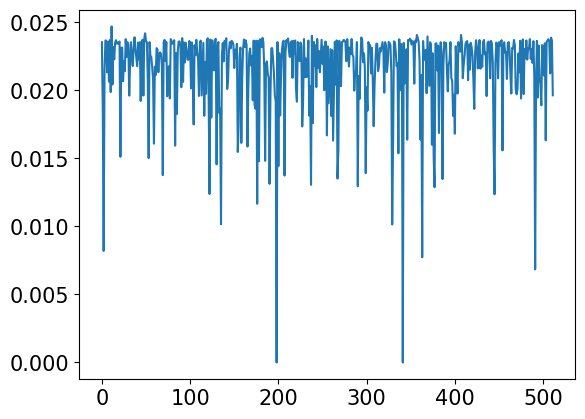

In [16]:
## TODO: Check whether the model is 'incorrectly' initialized !
x, y = next(iter(train_loader))
yp = jax.vmap(flow_model)(jnp.array(x))
plt.plot(yp)

## Train the flow model

In [17]:
flow_model_new, loss_train, loss_test = train_flow_model(
    flow_model, train_config['epochs'], mse, optim, train_loader, test_loader
    # flow_model, 10, mse, optim, train_loader, test_loader
)




Epoch 0
-----
Training loss: 0.005548240151256323
Test loss: 0.004928678274154663


Epoch 1
-----
Training loss: 0.003758826293051243
Test loss: 0.002920200815424323


Epoch 2
-----
Training loss: 0.0022380962036550045
Test loss: 0.002179414266720414


Epoch 3
-----
Training loss: 0.0017454620683565736
Test loss: 0.001589077990502119


Epoch 4
-----
Training loss: 0.0012772526824846864
Test loss: 0.0012613037833943963


Epoch 5
-----
Training loss: 0.001090656383894384
Test loss: 0.0010680557461455464


Epoch 6
-----
Training loss: 0.0010032447753474116
Test loss: 0.0010134757030755281


Epoch 7
-----
Training loss: 0.0009444875759072602
Test loss: 0.0010331989033147693


Epoch 8
-----
Training loss: 0.0009547491790726781
Test loss: 0.0009730362799018621


Epoch 9
-----
Training loss: 0.0009074807167053223
Test loss: 0.0009627725812606514


Epoch 10
-----
Training loss: 0.0008891968172974885
Test loss: 0.0009377025999128819


Epoch 11
-----
Training loss: 0.0008788348059169948
Test l

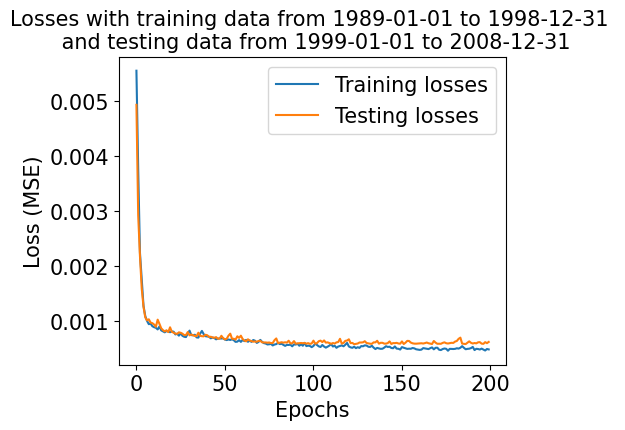

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(loss_train, label='Training losses')
ax.plot(loss_test, label='Testing losses')
ax.set(title=f'Losses with training data from {train_start} to {train_end} \n and testing data from {test_start} to {test_end}',
       ylabel='Loss (MSE)', xlabel='Epochs')
ax.legend(loc='upper right');


## Make predictions and get the hidden states for SAS arguments

In [19]:
flow_hidden_states = predict_dl(all_loader, flow_model.calculate_hidden_states)
Q_lstm = predict_dl(all_loader, flow_model)


# The transport model

## Get the transport model training data

In [20]:
# TODO: skip the initial days with sequence length used by LSTM model
cutoff_length = flow_dl_config['sequence_length']
df_cut = df.iloc[cutoff_length:]
J, Q, ET, C_J, C_Q_J, sTmT_init = get_fluxes_from_df(df_cut)


In [21]:
# SAS arguments
# sas_Q_args = flow_hidden_states
# sas_ET_args = flow_hidden_states
if flow_transport_coupling_type == 0:
    sas_Q_args = Q[:,None]
    sas_ET_args = ET[:,None]

elif flow_transport_coupling_type == 1:
    sas_Q_args = flow_hidden_states
    sas_ET_args = flow_hidden_states

elif flow_transport_coupling_type == 2:
    sas_Q_args = jnp.concat([flow_hidden_states, Q[:,None]], axis=1)
    sas_ET_args = jnp.concat([flow_hidden_states, ET[:,None]], axis=1)

else:
    sas_Q_args = Q[:,None]
    sas_ET_args = ET[:,None]
    

In [22]:
# Inputs and outputs
mask = jnp.where(~jnp.isnan(C_Q_J))
x = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask]
y = C_Q_J[mask][:,None]

# Traing data
# During training, we run the model until the end of the training period
mask_train = mask[0][(mask[0]>train_start_ind) & (mask[0]<train_end_ind)]
x_train = [e[:train_end_ind] for e in x[:-1]] + [mask_train]
y_train = C_Q_J[mask_train][:,None]

# Test data
# During test, we run the model throughout the whole period but evaluate only on the test period
mask_test = mask[0][(mask[0]>test_start_ind) & (mask[0]<test_end_ind)]
x_test = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask_test]
y_test = C_Q_J[mask_test][:,None]

y_train.shape, y_test.shape


((517, 1), (443, 1))

## Train the transport model

In [23]:
# Train the model
jax.clear_caches()
transport_model_new, loss_train_mdn, loss_test_mdn = train_transport_model(
    transport_model, train_config['epochs'], mse, optim, x_train, y_train, x_test, y_test
)


2025-02-18 12:53:47,741 - INFO - The loss of step 0: 1.5347357988357544
2025-02-18 12:54:23,242 - INFO - The loss of step 1: 1.4809834957122803
2025-02-18 12:54:44,266 - INFO - The loss of step 2: 1.4284453392028809
2025-02-18 12:54:52,384 - INFO - The loss of step 3: 1.3753334283828735
2025-02-18 12:55:00,434 - INFO - The loss of step 4: 1.3206661939620972
2025-02-18 12:55:08,480 - INFO - The loss of step 5: 1.2646597623825073
2025-02-18 12:55:16,519 - INFO - The loss of step 6: 1.2090450525283813
2025-02-18 12:55:24,543 - INFO - The loss of step 7: 1.1577324867248535
2025-02-18 12:55:32,566 - INFO - The loss of step 8: 1.1171494722366333
2025-02-18 12:55:40,605 - INFO - The loss of step 9: 1.0952054262161255
2025-02-18 12:55:48,637 - INFO - The loss of step 10: 1.0952850580215454
2025-02-18 12:55:56,672 - INFO - The loss of step 11: 1.1051279306411743
2025-02-18 12:56:04,702 - INFO - The loss of step 12: 1.1012698411941528
2025-02-18 12:56:12,732 - INFO - The loss of step 13: 1.07576

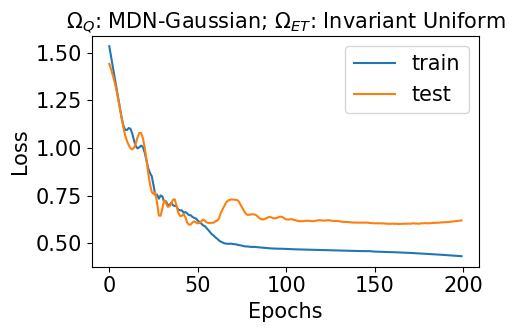

In [24]:
# Plot the loss
fig, ax = plt.subplots(1, 1, figsize=(5,3))
ax.plot(loss_train_mdn, label='train')
ax.plot(loss_test_mdn, label='test')
ax.set(xlabel='Epochs', ylabel='Loss', 
       title='$\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform')
ax.legend()


## Make predictions

In [25]:
# Run the trained model
sT, mT, mQETs, pQETs, mRs, C_Q = transport_model_new(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
df_cut['C_Q mdn'] = C_Q


/tmp/ipykernel_15994/490885752.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cut['C_Q mdn'] = C_Q


(<Figure size 1500x400 with 2 Axes>,
 <Axes: title={'center': 'Cl ($\\Omega_Q$: MDN-Gaussian; $\\Omega_{ET}$: Invariant Uniform)'}, xlabel='Time '>,
 <Axes: title={'center': ' (RMSE: 0.827; NSE: 0.518)'}, xlabel='Observation', ylabel='Simulation'>)

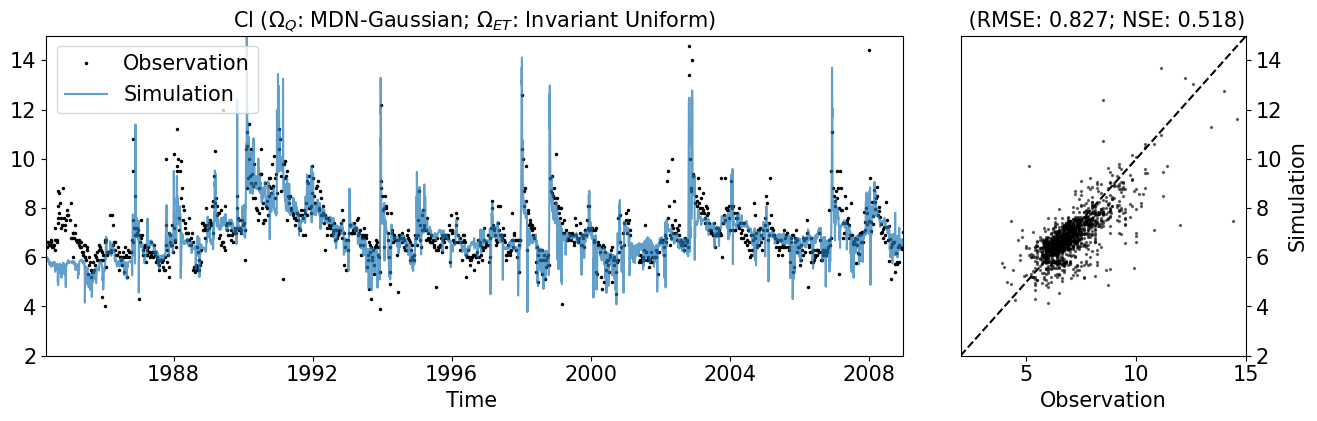

In [26]:
plot_timeseries_obs_1to1(
    obs=df_cut['Q Cl mg/l'].values, sim=df_cut['C_Q mdn'].values, lim=[2,15], timesteps=df_cut.index,
    varn='Cl ($\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform)'
)


(<Figure size 1500x400 with 2 Axes>,
 <Axes: title={'center': 'Cl ($\\Omega_Q$: MDN-Gaussian; $\\Omega_{ET}$: Invariant Uniform)'}, xlabel='Time '>,
 <Axes: title={'center': ' (RMSE: 0.772; NSE: 0.524)'}, xlabel='Observation', ylabel='Simulation'>)

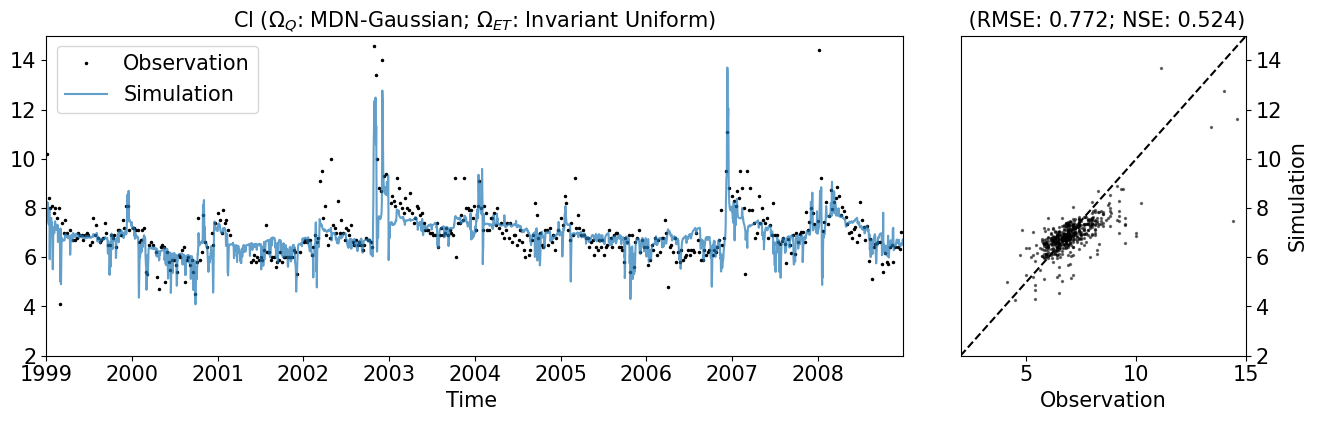

In [27]:
s, e = test_start, test_end
plot_timeseries_obs_1to1(
    obs=df_cut['Q Cl mg/l'][s:e].values, sim=df_cut['C_Q mdn'][s:e].values, lim=[2,15], 
    timesteps=df_cut[s:e].index,
    varn='Cl ($\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform)'
)


array([<Axes: title={'center': 'Q age distribution'}, ylabel='Age [Days]'>,
       <Axes: title={'center': 'ET age distribution'}, ylabel='Age [Days]'>],
      dtype=object)

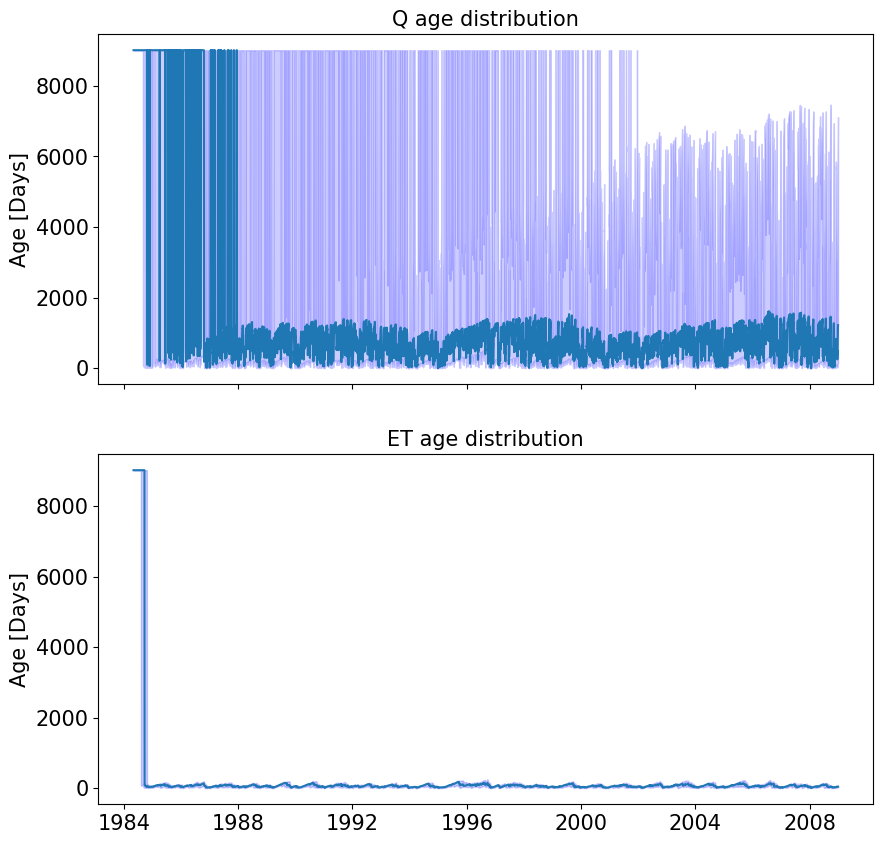

In [28]:
plot_PQET_quantile(pQETs, transport_params['transport_specs']['dt'], df_cut.index)


# Save the models

In [35]:
f_flow = f'flow_model_{model_label}.eqx'
f_transport = f'transport_model_{model_label}.eqx'
f_configs = f'configs-{model_label}.json'


In [59]:
# Save the overall configurations
configs = {
    "flow_configs": flow_params,
    "transport_configs": transport_params,
    "f_flow": f_flow,
    "f_transport": f_transport,
    "flow_loss": {
        "train": loss_train.tolist(),
        "test": loss_test.tolist()
    },
    "transport_loss": {
        "train": loss_train_mdn.tolist(),
        "test": loss_test_mdn.tolist()
    },
    "flow_dl_configs": flow_dl_config,
    "train_configs": train_config,
    "flow_transport_coupling_type": flow_transport_coupling_type,
    "f_data": "../" + f_data,
    "watershed_name": watershed_name
}

In [61]:
save_model(configs, flow_model_new, transport_model_new, f_configs)
# save_flow_model('./models/flow_model_mdn-gaussian-coupled.eqx', flow_params, flow_model_new)
# save_transport_model('./models/transport_model_mdn-gaussian-coupled.eqx', transport_params, transport_model_new)


# Load the models

In [62]:
model, loss, flow_dl, transport_data = load_model(f_configs)